# Access the CLMS data in the eodc stac

This notebook is a short overview on how to access the CLMS VPP data in the eodc stac

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray  # noqa: F401
from pyproj import Transformer
import pystac_client


Access the collection

In [3]:
eodc_catalog = pystac_client.Client.open("https://stac.eodc.eu/api/v1")

# Search the collection
results = eodc_catalog.search(
    collections=["clms-vpp"],
    
    bbox=[15.419565, 48.435618, 15.420367, 48.436191],
    datetime="2017-01-01/2024-12-31",
)


# list all items and their assets in the colletion
items = list(results.items())
print(f"Found {len(items)} items")
for item in items:
    print(item.id, item.assets.keys())

Found 14 items
TPROD dict_keys(['s1', 's2'])
SPROD dict_keys(['s1', 's2'])
SOSV dict_keys(['s1', 's2'])
SOSD dict_keys(['s1', 's2'])
RSLOPE dict_keys(['s1', 's2'])
QFLAG dict_keys(['s1', 's2'])
MINV dict_keys(['s1', 's2'])
MAXV dict_keys(['s1', 's2'])
MAXD dict_keys(['s1', 's2'])
LSLOPE dict_keys(['s1', 's2'])
LENGTH dict_keys(['s1', 's2'])
EOSV dict_keys(['s1', 's2'])
EOSD dict_keys(['s1', 's2'])
AMPL dict_keys(['s1', 's2'])


Access a specific item (parameter)

In [17]:
item_length = next(
    eodc_catalog.search(collections=["clms-vpp"], ids=["LENGTH"]).items()
)
print(item_length.properties)

# Set the season
asset_length_s1 = item_length.assets['s1']

# get url
store_url_length = asset_length_s1.href
print(store_url_length)
print(asset_length_s1.extra_fields)

{'title': 'LENGTH - Season Length', 'description': 'TIFFTAG_COPYRIGHT: Copernicus service information 2021,\n Scale factor: 1.0,\n Fill value: 0', 'end_datetime': '2024-12-31T00:00:00Z', 'start_datetime': '2017-01-01T00:00:00Z'}
https://objects.eodc.eu/68e13833a1624f43ba2cac01376a18af:CLMS/ZARR/clms_vpp.zarr
{'xarray:open_zarr_kwargs': {'group': 'LENGTH/s1', 'zarr_format': 3, 'consolidated': True, 'mask_and_scale': False}}


Open the dataset with xarray

In [18]:
length = xr.open_zarr(
    store_url_length,
    **asset_length_s1.extra_fields["xarray:open_zarr_kwargs"]
)

print(length)

<xarray.Dataset> Size: 112GB
Dimensions:  (time: 8, y: 50000, x: 70000)
Dimensions without coordinates: time, y, x
Data variables:
    data     (time, y, x) float32 112GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>


Select a bbox and plot the time series of all points inside

In [19]:
# Reproject bbox WGS84 → EPSG:3035 
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)
# 14.3140105188116866,48.3117521133462304 : 14.3156663397323243,48.3128676765390423

lon_min, lat_min = 14.3240105188116866, 48.3117521133462304
lon_max, lat_max = 14.3256663397323243, 48.3128676765390423

x_min, y_min = transformer.transform(lon_min, lat_min)
x_max, y_max = transformer.transform(lon_max, lat_max)

print(f"EPSG:3035 bbox: x=({x_min:.0f}, {x_max:.0f}), y=({y_min:.0f}, {y_max:.0f})")

EPSG:3035 bbox: x=(4641665, 4641781), y=(2809200, 2809331)


In [20]:
length = length.assign_coords(time=length["data"].attrs["years"])

# Assign spatial coordinates from transform
transform = length["data"].attrs["transform"]
res_x, _, left, _, neg_res_y, top = transform
height, width = length["data"].shape[1], length["data"].shape[2]

xs = left     + res_x     * np.arange(width)  + res_x     / 2
ys = top      + neg_res_y * np.arange(height) + neg_res_y / 2

length = length.assign_coords(x=("x", xs), y=("y", ys))

# Subset to bbox 
subset = length["data"].sel(
    x=slice(x_min, x_max),
    y=slice(y_max, y_min)  # y is descending
)
print(f"Subset shape: {subset.shape}  ({subset.shape[1] * subset.shape[2]} pixels)")

Subset shape: (8, 13, 11)  (143 pixels)


In [24]:
length

<xarray.Dataset> Size: 112GB
Dimensions:  (time: 8, y: 50000, x: 70000)
Coordinates:
  * time     (time) int64 64B 2017 2018 2019 2020 2021 2022 2023 2024
  * y        (y) float64 400kB 3e+06 3e+06 3e+06 ... 2.5e+06 2.5e+06 2.5e+06
  * x        (x) float64 560kB 4.2e+06 4.2e+06 4.2e+06 ... 4.9e+06 4.9e+06
Data variables:
    data     (time, y, x) float32 112GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>

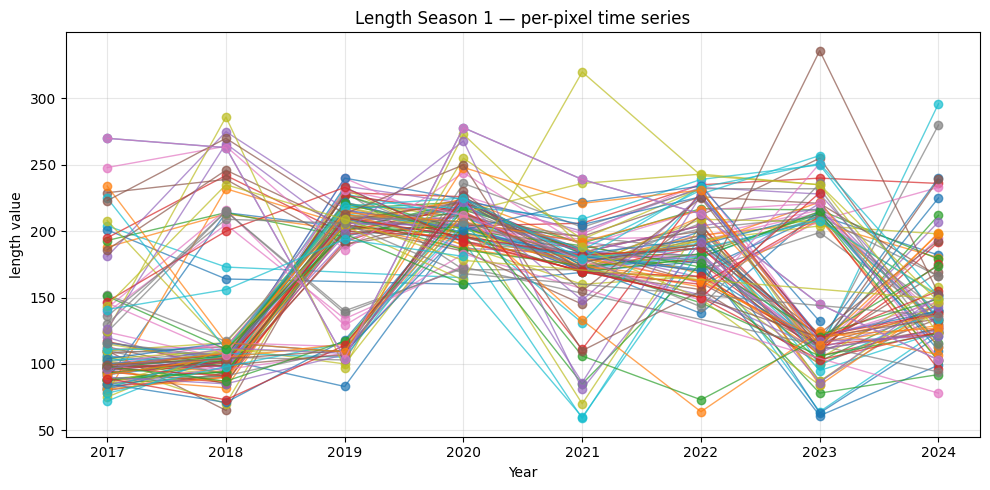

In [21]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))

years = subset.coords["time"].values

for row in range(subset.shape[1]):
    for col in range(subset.shape[2]):
        values = subset[:, row, col].values
        mask   = np.isfinite(values)
        if mask.any():
            ax.plot(
                years[mask], values[mask],
                marker="o", linewidth=1, alpha=0.7,
                label=f"({row},{col})"
            )

ax.set_title("Length Season 1 — per-pixel time series")
ax.set_xlabel("Year")
ax.set_ylabel("length value")
#ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Select a different item

In [41]:
item_EOSV = next(
    eodc_catalog.search(collections=["clms-vpp"], ids=["EOSV"]).items()
)
print(item_EOSV.properties)

# Set the season
asset_eosv_s1 = item_EOSV.assets['s1']

# get url
store_url_eosv = asset_eosv_s1.href
print(store_url_eosv)
print(asset_eosv_s1.extra_fields)

{'title': 'EOSV - End of season value', 'description': 'TIFFTAG_COPYRIGHT: Copernicus service information 2021,\n Scale factor: 0.0001,\n Fill value: -32768', 'end_datetime': '2024-12-31T00:00:00Z', 'start_datetime': '2017-01-01T00:00:00Z'}
https://objects.eodc.eu/68e13833a1624f43ba2cac01376a18af:CLMS/ZARR/clms_vpp.zarr
{'xarray:open_zarr_kwargs': {'group': 'EOSV/s1', 'zarr_format': 3, 'consolidated': True, 'mask_and_scale': False}}


In [42]:
eosv = xr.open_zarr(
    store_url_eosv,
    **asset_eosv_s1.extra_fields["xarray:open_zarr_kwargs"]
)

print(eosv)

<xarray.Dataset> Size: 112GB
Dimensions:  (time: 8, y: 50000, x: 70000)
Dimensions without coordinates: time, y, x
Data variables:
    data     (time, y, x) float32 112GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>


Select a bbox and print all values from 2022

In [43]:
eosv = eosv.assign_coords(time=eosv["data"].attrs["years"])
eosv_2022 = eosv.sel(time=2022)

subset_eosv = eosv_2022["data"].rio.clip_box(
    minx=4684826.96,
    miny=2723295.68,
    maxx=4685338.75,
    maxy=2723808.54,
)

print(subset_eosv.compute())

<xarray.DataArray 'data' (y: 52, x: 52)> Size: 11kB
array([[0.3217    , 0.25329998, 0.3699    , ..., 0.2669    , 0.15879999,
        0.123     ],
       [0.295     , 0.26729998, 0.3746    , ..., 0.3117    , 0.17809999,
        0.29459998],
       [0.2643    , 0.2846    , 0.3344    , ..., 0.29119998, 0.27809998,
        0.40019998],
       ...,
       [0.317     , 0.3322    , 0.3874    , ..., 0.2254    , 0.24229999,
        0.2582    ],
       [0.3849    , 0.2871    , 0.3964    , ..., 0.25849998, 0.2174    ,
        0.2181    ],
       [0.54609996, 0.3875    , 0.35529998, ..., 0.20979999, 0.18079999,
        0.1787    ]], shape=(52, 52), dtype=float32)
Coordinates:
    time         int64 8B 2022
    spatial_ref  int64 8B 0
Dimensions without coordinates: y, x
Attributes:
    long_name:       End of season value
    scale_factor:    0.0001
    _FillValue_raw:  -32768
    years:           [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
